# 0 - Setup: ambiente, dataset e checkpoint

This is the first of a collection of files required to run the Computer Vision Project we implemented.  
Here we set up the setup, downloading the new dataset(s) and checkpoint(s).  

We have decided to use the **LoveDA** dataset(https://github.com/Junjue-Wang/LoveDA), which cointeins aerial images with a resolution of 1024x1024, 7 different classes, with a domain of Urban+Rurual. We chose this one because its domain is very far from COCO/Adse20K, and we wanted to test the adaptability of this architecture.  

For the checkpoints of the model, we have decided to use the **EoMTS-S** based on ViT-S DINOv2 with ~24M parameters because of the GPU we had (RTX 5070 and ??) 

Some utilities functions are present in the folder `finetuning/`; DataModule of the dataset is in `datasets/loveda_semantic.py`.

## 1. Environment check
Given the size of the model, we suggest using **cuda**

In [1]:
import torch

print(f"PyTorch    : {torch.__version__}")
print(f"CUDA       : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU        : {props.name}")
    print(f"VRAM       : {props.total_memory / 1e9:.1f} GB")
    print(f"Capability : sm_{props.major}{props.minor}")
assert torch.cuda.is_available(), "CUDA non disponibile: controlla l'installazione di PyTorch"

PyTorch    : 2.7.0+cu128
CUDA       : True
GPU        : NVIDIA GeForce RTX 5070
VRAM       : 12.8 GB
Capability : sm_120


## 2. Download of LoveDA dataset (from Zenodo)

`Train.zip` (~4.0 GB, 2506 images); `Val.zip` (~2.4 GB, 1652 images), **with public mask** (the test set does no have them, so we had to use Val set).  
The files are kept zipped as the original pipeline works in this way.   

In [2]:
from finetuning.download import download_loveda

DATA_DIR = download_loveda("data/loveda")
print(f"Dataset in: {DATA_DIR.resolve()}")

c:\Users\VGa\Documents\GitHub\eomt-ComputerVisionProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Train.zip: 100%|██████████| 4.02G/4.02G [00:20<00:00, 197MB/s] 
Val.zip: 100%|██████████| 2.43G/2.43G [01:24<00:00, 28.7MB/s]

Dataset in: C:\Users\VGa\Documents\GitHub\eomt-ComputerVisionProject\data\loveda


In [ ]:
# Sanity check for the path
# hardcoded in datasets/loveda_semantic.py (Train/Urban/images_png/... ecc.)
import zipfile

for zip_name in ["Train.zip", "Val.zip"]:
    with zipfile.ZipFile(DATA_DIR / zip_name) as zf:
        names = zf.namelist()
        pngs = [n for n in names if n.endswith(".png")]
        print(f"{zip_name}: {len(pngs)} png — esempi:")
        for n in pngs[:2] + pngs[-2:]:
            print(f"   {n}")

Train.zip: 5044 png — esempi:
   Train/Rural/images_png/0.png
   Train/Rural/images_png/1.png
   Train/Urban/masks_png/2520.png
   Train/Urban/masks_png/2521.png
Val.zip: 3338 png — esempi:
   Val/Rural/images_png/2522.png
   Val/Rural/images_png/2523.png
   Val/Urban/masks_png/4189.png
   Val/Urban/masks_png/4190.png


## 3. Download of checkpoint (EoMT-S on COCO panoptic)

In [4]:
from finetuning.download import download_coco_checkpoint

CKPT_PATH = download_coco_checkpoint("checkpoints")
print(f"Checkpoint in: {CKPT_PATH.resolve()}")

coco_panoptic_eomt_small_640_2x.bin: 100%|██████████| 96.0M/96.0M [00:28<00:00, 3.37MB/s]

Checkpoint in: C:\Users\VGa\Documents\GitHub\eomt-ComputerVisionProject\checkpoints\coco_panoptic_eomt_small_640_2x.bin


## 4. Sanity check of the DataModule

Using `LoveDASemantic` we show some pairs img/mask of the Validation Set.

In [5]:
from datasets.loveda_semantic import LoveDASemantic

dm = LoveDASemantic(path=str(DATA_DIR), batch_size=2, num_workers=0).setup()
print(f"Train: {len(dm.train_dataset)} immagini | Val: {len(dm.val_dataset)} immagini")

Train: 2506 immagini | Val: 1652 immagini


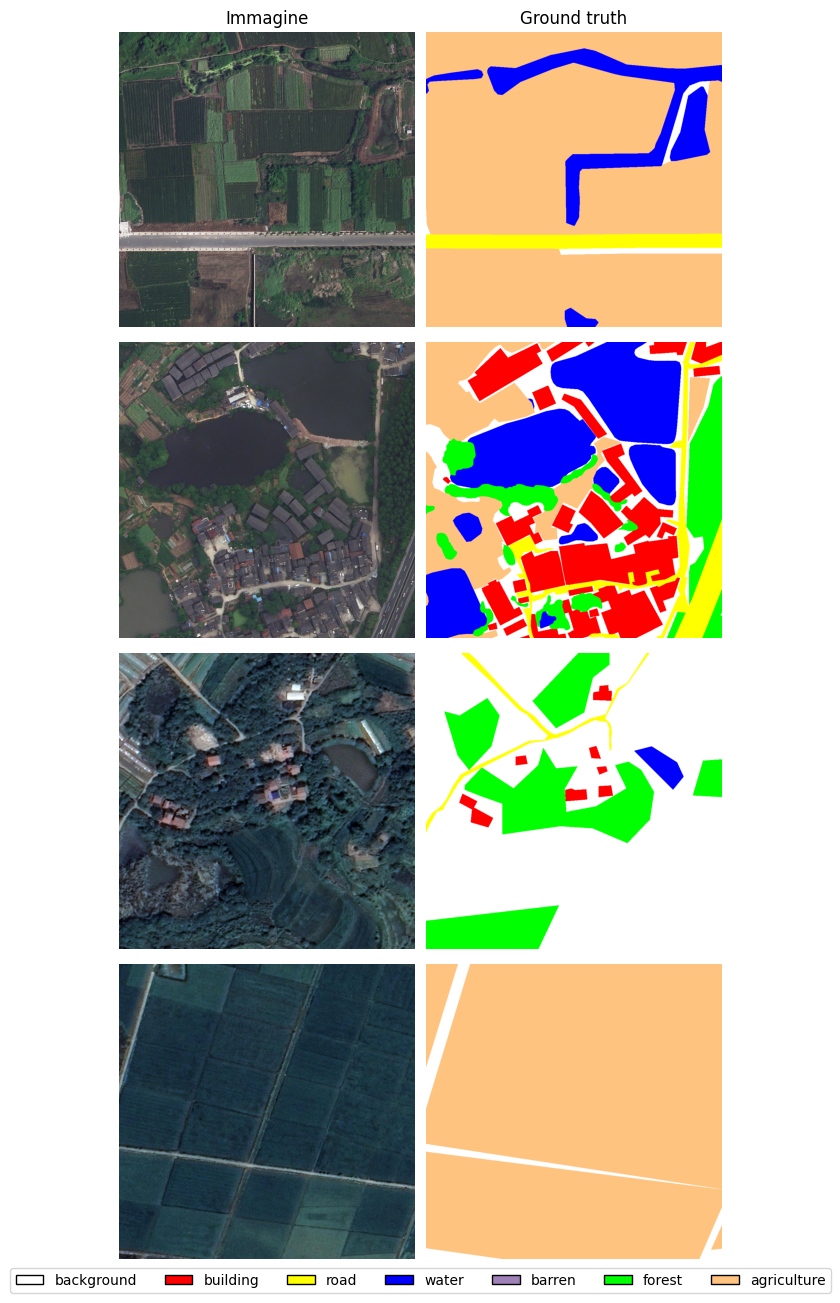

In [ ]:
from finetuning.visualize import get_val_samples, show_samples

indices = [0, 100, len(dm.val_dataset) - 200, len(dm.val_dataset) - 1]
imgs, targets = get_val_samples(dm, indices)
show_samples(imgs, targets)